## Simulating a complete set of data (calibration + science) for testing the DRP

In [9]:
import numpy as np
import astropy.units as u
import scopesim as sim
import scopesim_templates as sim_tp

from zs_scopesim_tools.helpers import (disable_scopesim_top_level_catch, warning_prevent_sync_alt_ra_dec, ignore_warnings,
                                       set_scopesim_log_level, make_local_output_dir, configure_irdb_path,
                                       list_effects, simulate, save_zshooter_readout)

configure_irdb_path()  ## tried to make it run automatically in bootstrap_env but didn't work, should find a way though
# set up log toggels
set_scopesim_log_level("warning")
disable_scopesim_top_level_catch()
ignore_warnings()

# set up output directory
output_dir = make_local_output_dir(dirname="sims")

In [2]:
# load instrument configs
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

In [10]:
# display list of effects
df = list_effects(cmd)
df

,config,alias,effect,class,include
0,MaunaKea,ATMO,atmo_transmission,TERCurve,True
1,MaunaKea,ATMO,continuum_emission,SkyBackgroundTERCurve,True
2,MaunaKea,ATMO,airglow_and_interline_continuum,PalaceAirglowEmission,True
3,MaunaKea,ATMO,seeing_psf,AOEnhanceablePSF,True
4,MaunaKea,ATMO,adc_residuals,ADCShift,True
5,keck,TEL,telescope_reflection,SurfaceList,True
6,ZShooter,INST,dichroic_tree,DichroicTree,True
7,ZShooter,INST,slitwheel_selector,SelectorWheel,True
8,ZShooter,INST,channel_optics_selector,SelectorWheel,True
9,ZShooter,INST,ir_blocking_filter_selector,SelectorWheel,False


### Create sources

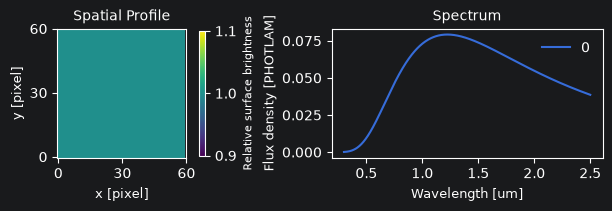

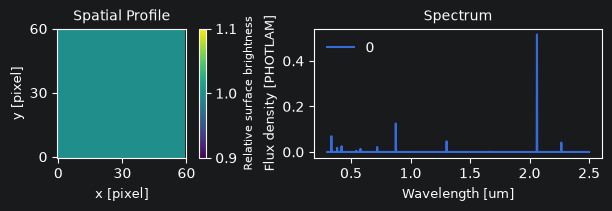

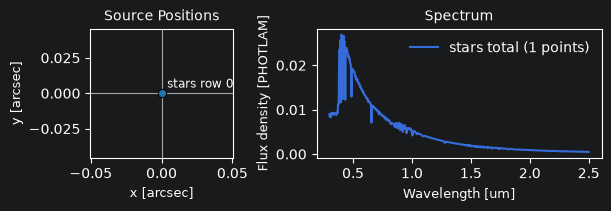

In [4]:
# create flat source
domeflat = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=12*u.ABmag, filter_curve='V', extend=60)
# create arc source
from zs_scopesim_tools.sources import lamp_flat
lamp = lamp_flat(scale_amplitude=1e-5)
# create science source
star = sim_tp.star(filter_name='V', amplitude=12*u.ABmag)

from zs_scopesim_tools.plots import PlotScene
plotter = PlotScene()
_ = plotter.from_source(domeflat)
_ = plotter.from_source(lamp)
_ = plotter.from_source(star)

 I have defined a dictionary of exposures to make it easier to loop through simulations with different properties (a.k.a. values of the keys in cmd dict like !OBS.dit_blue, !OBS.airmass, etc.). The keys of this dictionary are target names, the values are nested dicts with two keys: "props" - containing all the properties to update in cmd, and "source" - containing the source object to simulate.

In [5]:
exposures = {"domeflat": {"props": {"!OBS.dit_blue": 60, "!OBS.dit_green": 5, "!OBS.dit_red": 1,
                                    "!OBS.dit_yj": 1, "!OBS.dit_h": 1, "!OBS.dit_k": 1,
                                    "!OBS.ndit_blue": 1, "!OBS.ndit_green": 1, "!OBS.ndit_red": 1,
                                    "!OBS.ndit_yj": 1, "!OBS.ndit_h": 1, "!OBS.ndit_k": 1},
                          "source": domeflat},
             "arcs": {"props": {"!OBS.dit_blue": 10, "!OBS.dit_green": 1, "!OBS.dit_red": 1,
                                    "!OBS.dit_yj": 1, "!OBS.dit_h": 1, "!OBS.dit_k": 1,
                                    "!OBS.ndit_blue": 1, "!OBS.ndit_green": 1, "!OBS.ndit_red": 1,
                                    "!OBS.ndit_yj": 1, "!OBS.ndit_h": 1, "!OBS.ndit_k": 1},
                      "source": lamp},
             "bias": {"props": {"!OBS.dit_blue": 0, "!OBS.dit_green": 0, "!OBS.dit_red": 0,
                                    "!OBS.dit_yj": 0, "!OBS.dit_h": 0, "!OBS.dit_k": 0,
                                    "!OBS.ndit_blue": 1, "!OBS.ndit_green": 1, "!OBS.ndit_red": 1,
                                    "!OBS.ndit_yj": 1, "!OBS.ndit_h": 1, "!OBS.ndit_k": 1},
                      "source": None},
             "star": {"props": {"!OBS.dit_blue": 300, "!OBS.dit_green": 300, "!OBS.dit_red": 300,
                                    "!OBS.dit_yj": 300, "!OBS.dit_h": 300, "!OBS.dit_k": 300,
                                    "!OBS.ndit_blue": 1, "!OBS.ndit_green": 1, "!OBS.ndit_red": 1,
                                    "!OBS.ndit_yj": 1, "!OBS.ndit_h": 1, "!OBS.ndit_k": 1},
                      "source": star}}

### Simulate calibration sources

In [6]:
from zs_scopesim_tools.helpers import simulate
# disable all sky effects
disable_effects = ["atmo_transmission", "continuum_emission", "airglow_and_interline_continuum",
                   "seeing_psf", "adc_residuals"]

rawsims = {}
for obj in ["domeflat", "arcs", "bias"]:
    val = exposures[obj]
    print(f"Simulating {obj}...")
    # update any cmd keys for this exposure
    cmd.update_alias(cmd, val["props"])
    zs, hdul = simulate(cmd, source=val["source"], disable_effects=disable_effects, hide_progress_bars=True)
    # check desired counts
    print(f'Max counts: {[np.max(hdu[1].data) for hdu in hdul]}')
    rawsims[obj] = hdul
    break


Simulating domeflat...
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.


 FOVs:   0%|          | 0/127 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

...

 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

Max counts: [np.float64(3609.9664436576923), np.float64(32004.883001059614), np.float64(121922.06849639288), np.float64(171540.03506799383), np.float64(192024.27230637657), np.float64(181296.69004765563)]


In [7]:
hdul # list of HDULists, =len(channels) = 6, each HDUList has 2 HDUs: [0] primary, [1] image

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1150c8620>, <astropy.io.fits.hdu.image.ImageHDU object at 0x11572e120>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1160fbe30>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1150c8d10>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1150c8530>, <astropy.io.fits.hdu.image.ImageHDU object at 0x114fe07d0>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x114fe3c80>, <astropy.io.fits.hdu.image.ImageHDU object at 0x114fd9c10>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x11533f8f0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x115163d70>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1151634d0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x115163440>]]

Save the simulated data. The helper function can add cmd keys/values as extra header keywords to the FITS files for later reference before saving.

In [8]:
from zs_scopesim_tools.helpers import save_zshooter_readout

for obj in ["domeflat", "arcs", "bias"]:
    save_zshooter_readout(rawsims[obj], output_dir=output_dir, filename_prefix=obj, imagetype=obj.upper(), cmds=cmd, train=zs)
    break